# Skin Cancer Classification Using Convolutional Neural Networks
Name:Jasmine Ali Khan , Student ID: 2406768 , AI & ML Module: 6CS012

In [ ]:
# Mount drive and set paths first
from google.colab import drive
drive.mount('/content/drive')

import os
DATASET_PATH = '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Skin Cancer Classification'
TRAIN_PATH = os.path.join(DATASET_PATH, 'Train')
TEST_PATH  = os.path.join(DATASET_PATH, 'Test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Exploration and Preprocessing

In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Skin Cancer Classification'
TRAIN_PATH = os.path.join(DATASET_PATH, 'Train')
TEST_PATH  = os.path.join(DATASET_PATH, 'Test')

print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists:",  os.path.exists(TEST_PATH))
print("Classes:", os.listdir(TRAIN_PATH))

Train exists: True
Test exists: True
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


📦 DATA SIZE
Train images : 2239
Test images  : 118
Total        : 2357

📊 CLASS DISTRIBUTION
Class                             Train     Test
------------------------------------------------
actinic keratosis                   114       16
basal cell carcinoma                376       16
dermatofibroma                       95       16
melanoma                            438       16
nevus                               357       16
pigmented benign keratosis          462       16
seborrheic keratosis                 77        3
squamous cell carcinoma             181       16
vascular lesion                     139        3


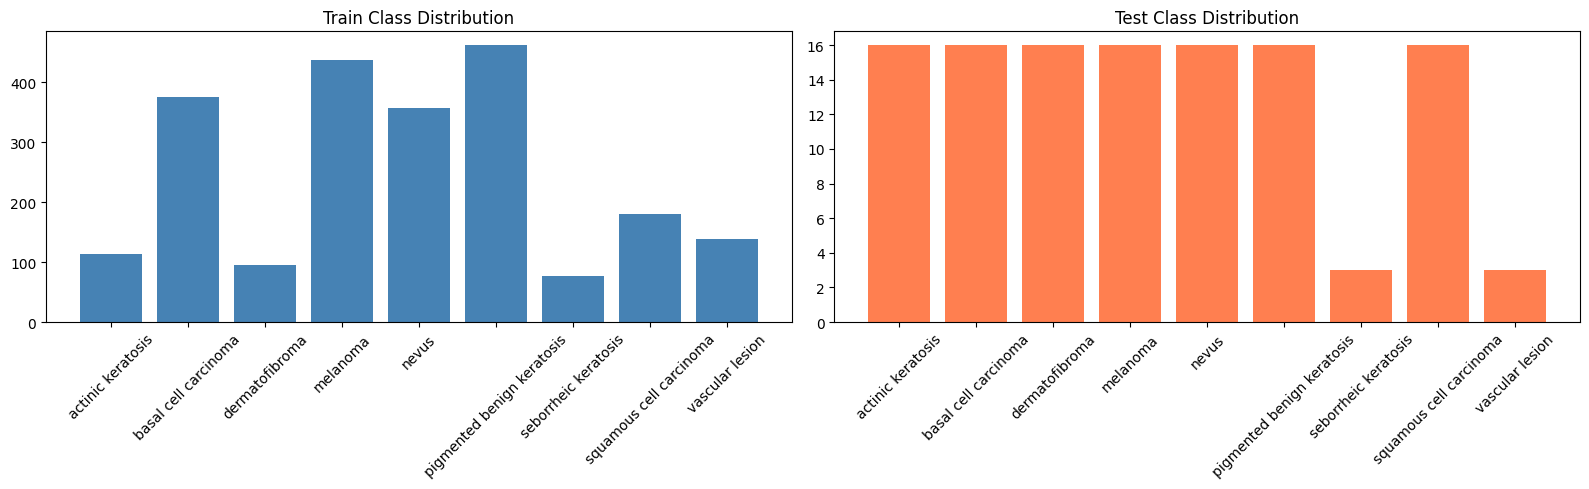


🖼️  PIXEL SIZES
Unique sizes found: 12
  600px  x  450px
  722px  x  542px
  722px  x  545px
  944px  x  1127px
  960px  x  724px
  962px  x  645px
  962px  x  674px
  964px  x  720px
  965px  x  624px
  966px  x  638px
  1024px  x  768px
  1504px  x  1129px

🔍 CORRUPTED IMAGE CHECK
Total Checked : 2357
Corrupted     : 63
  [Train] actinic keratosis/ISIC_0029460.jpg — cannot identify image file '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Skin Cancer Classification/Train/actinic keratosis/ISIC_0029460.jpg'
  [Train] actinic keratosis/ISIC_0027958.jpg — cannot identify image file '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Skin Cancer Classification/Train/actinic keratosis/ISIC_0027958.jpg'
  [Train] actinic keratosis/ISIC_0030036.jpg — cannot identify image file '/content/drive/MyDrive/2025 - 6CS012 - Datasets/Skin Cancer Classification/Train/actinic keratosis/ISIC_0030036.jpg'
  [Train] actinic keratosis/ISIC_0030730.jpg — cannot identify image file '/content/drive/MyDrive/2

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

train_classes = [c for c in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, c))]
test_classes  = [c for c in os.listdir(TEST_PATH)  if os.path.isdir(os.path.join(TEST_PATH, c))]

# ── 1. DATA SIZE ──────────────────────────────────────
print("=" * 55)
print("📦 DATA SIZE")
print("=" * 55)
total_train = sum(len(os.listdir(os.path.join(TRAIN_PATH, c))) for c in train_classes)
total_test  = sum(len(os.listdir(os.path.join(TEST_PATH,  c))) for c in test_classes)
print(f"Train images : {total_train}")
print(f"Test images  : {total_test}")
print(f"Total        : {total_train + total_test}")

# ── 2. CLASS DISTRIBUTION ─────────────────────────────
print("\n" + "=" * 55)
print("📊 CLASS DISTRIBUTION")
print("=" * 55)
train_dist = {c: len(os.listdir(os.path.join(TRAIN_PATH, c))) for c in train_classes}
test_dist  = {c: len(os.listdir(os.path.join(TEST_PATH,  c))) for c in test_classes}
print(f"{'Class':<30} {'Train':>8} {'Test':>8}")
print("-" * 48)
for c in sorted(train_dist):
    print(f"{c:<30} {train_dist[c]:>8} {test_dist.get(c,0):>8}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(train_dist.keys(), train_dist.values(), color='steelblue')
axes[0].set_title('Train Class Distribution')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(test_dist.keys(), test_dist.values(), color='coral')
axes[1].set_title('Test Class Distribution')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── 3. PIXEL SIZE ─────────────────────────────────────
print("\n" + "=" * 55)
print("🖼️  PIXEL SIZES")
print("=" * 55)
sizes = []
for c in train_classes:
    folder = os.path.join(TRAIN_PATH, c)
    for fname in os.listdir(folder)[:20]:
        try:
            img = Image.open(os.path.join(folder, fname))
            sizes.append(img.size)
        except:
            pass
unique_sizes = set(sizes)
print(f"Unique sizes found: {len(unique_sizes)}")
for s in sorted(unique_sizes):
    print(f"  {s[0]}px  x  {s[1]}px")

# ── 4. CORRUPTED IMAGES ───────────────────────────────
print("\n" + "=" * 55)
print("🔍 CORRUPTED IMAGE CHECK")
print("=" * 55)
corrupted = []
total_checked = 0
for split, path in [('Train', TRAIN_PATH), ('Test', TEST_PATH)]:
    for c in os.listdir(path):
        folder = os.path.join(path, c)
        if not os.path.isdir(folder): continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            total_checked += 1
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception as e:
                corrupted.append((split, c, fname, str(e)))
print(f"Total Checked : {total_checked}")
print(f"Corrupted     : {len(corrupted)}")
if corrupted:
    for item in corrupted:
        print(f"  [{item[0]}] {item[1]}/{item[2]} — {item[3]}")
else:
    print("✅ No corrupted images found!")

# ── 5. AUGMENTATION ───────────────────────────────────
print("\n" + "=" * 55)
print("⚙️  AUGMENTATION METHODS")
print("=" * 55)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip    = True,
    vertical_flip      = True,
    zoom_range         = 0.2,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Augmentation defined! Methods applied:")
print("   • Rescaling, Rotation ±20°, Width/Height shift")
print("   • Horizontal & Vertical flip")
print("   • Zoom ±20%, Brightness ±20%")

In [ ]:
import os
from PIL import Image

# Check pixel size from a sample of images
sample_sizes = []
for folder in os.listdir(TRAIN_PATH):
    folder_path = os.path.join(TRAIN_PATH, folder)
    if os.path.isdir(folder_path):
        for img_file in os.listdir(folder_path)[:3]:  # sample 3 per class
            img_path = os.path.join(folder_path, img_file)
            try:
                with Image.open(img_path) as img:
                    sample_sizes.append(img.size)
            except:
                pass

unique_sizes = set(sample_sizes)
print(f"Unique pixel sizes found: {unique_sizes}")
print(f"Most common size: {max(set(sample_sizes), key=sample_sizes.count)}")

Unique pixel sizes found: {(965, 624), (600, 450), (722, 542), (1024, 768), (1504, 1129), (962, 645)}
Most common size: (600, 450)


Class Distribution:
  actinic keratosis: 114 images
  basal cell carcinoma: 376 images
  dermatofibroma: 95 images
  melanoma: 438 images
  nevus: 357 images
  pigmented benign keratosis: 462 images
  seborrheic keratosis: 77 images
  squamous cell carcinoma: 181 images
  vascular lesion: 139 images


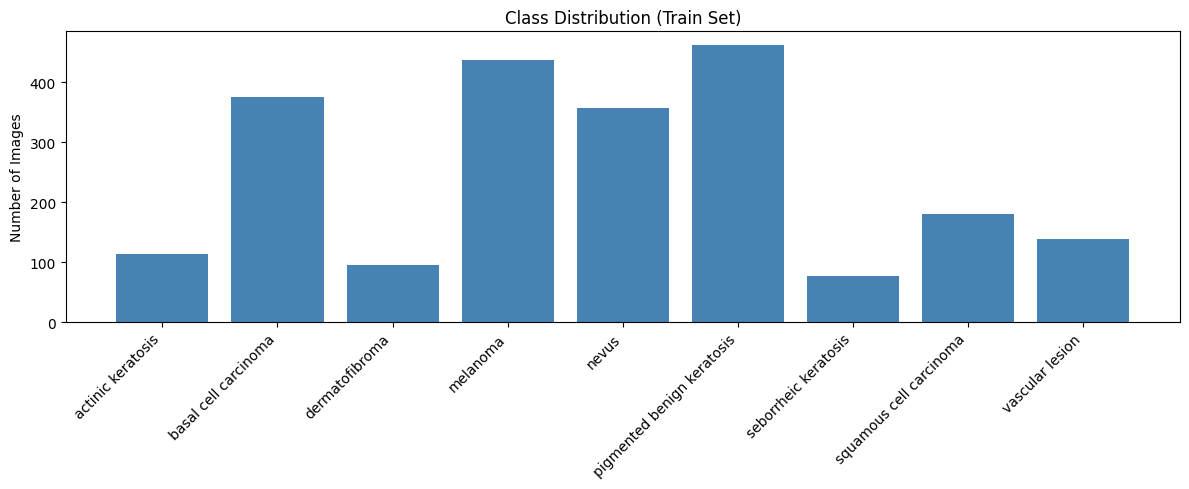

In [ ]:
import matplotlib.pyplot as plt

class_counts = {}
for folder in os.listdir(TRAIN_PATH):
    folder_path = os.path.join(TRAIN_PATH, folder)
    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

print("Class Distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count} images")

# Plot it
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

Class Distribution:
  actinic keratosis: 114 images
  basal cell carcinoma: 376 images
  dermatofibroma: 95 images
  melanoma: 438 images
  nevus: 357 images
  pigmented benign keratosis: 462 images
  seborrheic keratosis: 77 images
  squamous cell carcinoma: 181 images
  vascular lesion: 139 images


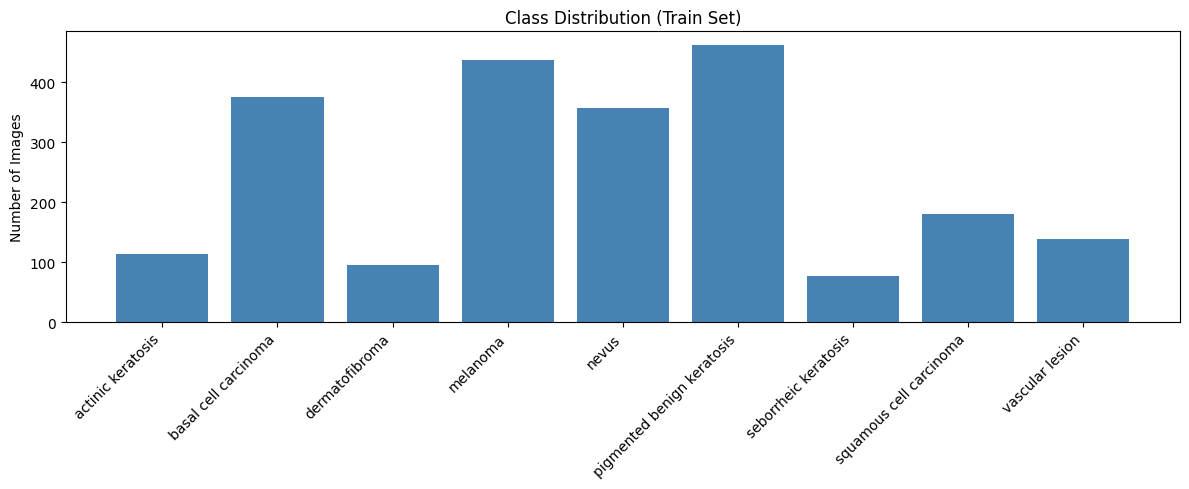

In [ ]:
import matplotlib.pyplot as plt

class_counts = {}
for folder in os.listdir(TRAIN_PATH):
    folder_path = os.path.join(TRAIN_PATH, folder)
    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

print("Class Distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count} images")

# Plot it
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [ ]:
import os

def get_dataset_size(directory):
    total_images = 0
    total_size_bytes = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total_images += 1
                total_size_bytes += os.path.getsize(os.path.join(root, file))
    return total_images, total_size_bytes / (1024 ** 2)  # MB

train_imgs, train_mb = get_dataset_size(TRAIN_PATH)
print(f"Train → {train_imgs} images | {train_mb:.2f} MB")

# If you have a test/val dir:
# test_imgs, test_mb = get_dataset_size(test_dir)
# print(f"Test  → {test_imgs} images | {test_mb:.2f} MB")

Train → 2239 images | 588.07 MB


In [ ]:
print("\n" + "="*40)
print("AUGMENTATION SUMMARY")
print("="*40)
aug_config = {
    "Rescale": "1/255",
    "Rotation Range": "20°",
    "Width/Height Shift": "0.1",
    "Horizontal Flip": True,
    "Vertical Flip": True,
    "Zoom Range": "0.1",
    "Brightness Range": "[0.8, 1.2]",
    "Fill Mode": "nearest"
}
for key, val in aug_config.items():
    print(f"  ✔ {key}: {val}")


AUGMENTATION SUMMARY
  ✔ Rescale: 1/255
  ✔ Rotation Range: 20°
  ✔ Width/Height Shift: 0.1
  ✔ Horizontal Flip: True
  ✔ Vertical Flip: True
  ✔ Zoom Range: 0.1
  ✔ Brightness Range: [0.8, 1.2]
  ✔ Fill Mode: nearest


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2  # 20% of train used for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print("Classes:", train_gen.class_indices)
print(f"Train batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}")

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Classes: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Train batches: 57 | Val batches: 14 | Test batches: 4


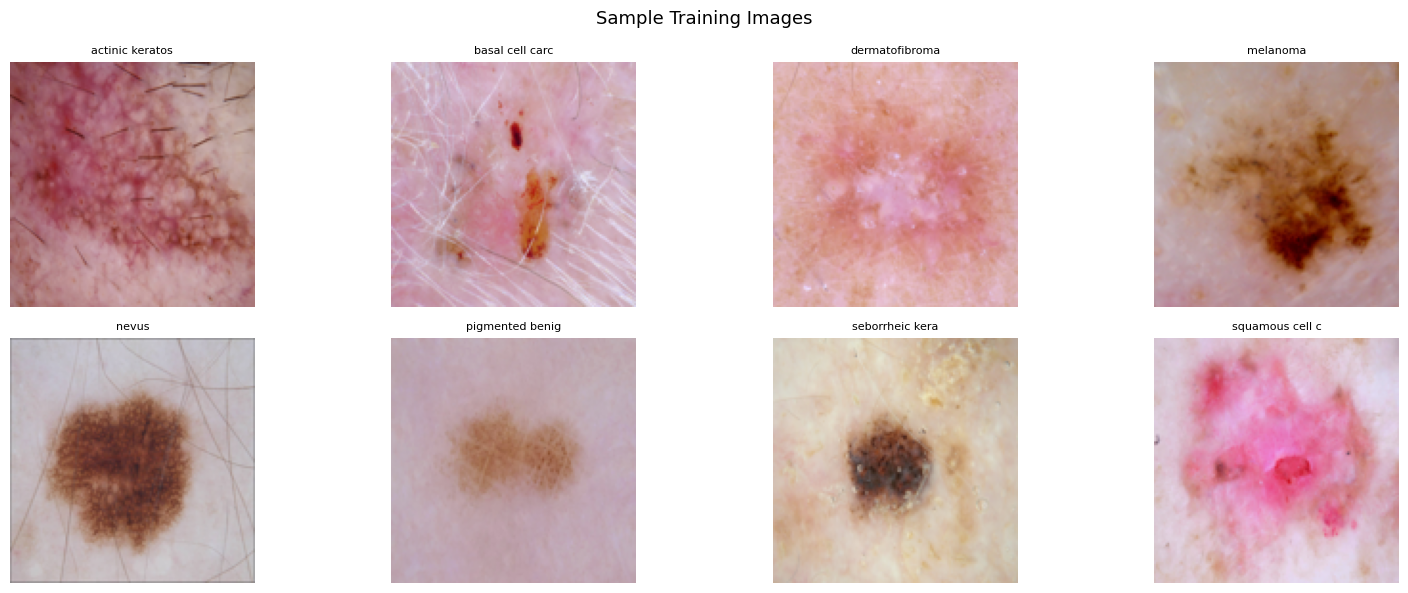

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
shown = 0
for class_name in class_names:
    if shown >= 8:
        break
    folder = os.path.join(TRAIN_PATH, class_name)
    for fname in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB').resize((128,128))
            axes[shown//4][shown%4].imshow(np.array(img)/255.)
            axes[shown//4][shown%4].set_title(class_name[:15], fontsize=8)
            axes[shown//4][shown%4].axis('off')
            shown += 1
            break
        except:
            continue

plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

#2. Part A — CNN Models from Scratch
### Model 1: Baseline CNN
A simple CNN with 2 convolutional layers trained as a baseline model.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(42)

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,481 (28.20 MB)

 Trainable params: 7,393,481 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os, shutil
from PIL import Image

LOCAL_TRAIN = '/tmp/skin/Train'
LOCAL_TEST  = '/tmp/skin/Test'
os.makedirs(LOCAL_TRAIN, exist_ok=True)
os.makedirs(LOCAL_TEST,  exist_ok=True)

# Copy valid training images only
copied, skipped = 0, 0
for cls in os.listdir(TRAIN_PATH):
    src_cls = os.path.join(TRAIN_PATH, cls)
    dst_cls = os.path.join(LOCAL_TRAIN, cls)
    if not os.path.isdir(src_cls): continue
    os.makedirs(dst_cls, exist_ok=True)
    for fname in os.listdir(src_cls):
        src = os.path.join(src_cls, fname)
        try:
            Image.open(src).verify()
            shutil.copy2(src, os.path.join(dst_cls, fname))
            copied += 1
        except:
            skipped += 1

# Copy test images
for cls in os.listdir(TEST_PATH):
    src_cls = os.path.join(TEST_PATH, cls)
    dst_cls = os.path.join(LOCAL_TEST, cls)
    if not os.path.isdir(src_cls): continue
    os.makedirs(dst_cls, exist_ok=True)
    for fname in os.listdir(src_cls):
        shutil.copy2(os.path.join(src_cls, fname), os.path.join(dst_cls, fname))

TRAIN_PATH = LOCAL_TRAIN
TEST_PATH  = LOCAL_TEST
print(f"Done! Copied {copied} valid images, skipped {skipped} corrupted.")

Done! Copied 2176 valid images, skipped 63 corrupted.


In [ ]:
# Recreate generators after removing corrupted files
train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("Generators recreated!")

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Generators recreated!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(42)

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,481 (28.20 MB)

 Trainable params: 7,393,481 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history1 = model1.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[early_stop]
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.2196 - loss: 2.3076 - val_accuracy: 0.1690 - val_loss: 1.9402
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3142 - loss: 1.8949 - val_accuracy: 0.3657 - val_loss: 1.8794
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3870 - loss: 1.7441 - val_accuracy: 0.3796 - val_loss: 1.7692
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4438 - loss: 1.6452 - val_accuracy: 0.4028 - val_loss: 1.8470
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4530 - loss: 1.5877 - val_accuracy: 0.4815 - val_loss: 1.6698
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4794 - loss: 1.5048 - val_accuracy: 0.4421 - val_loss: 1.7602
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5143 - loss: 1.4527 - val_accuracy: 0.4421 - val_loss: 1.6221
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5132 - loss: 1.4513 - val_accuracy: 0.4213 - val_loss:

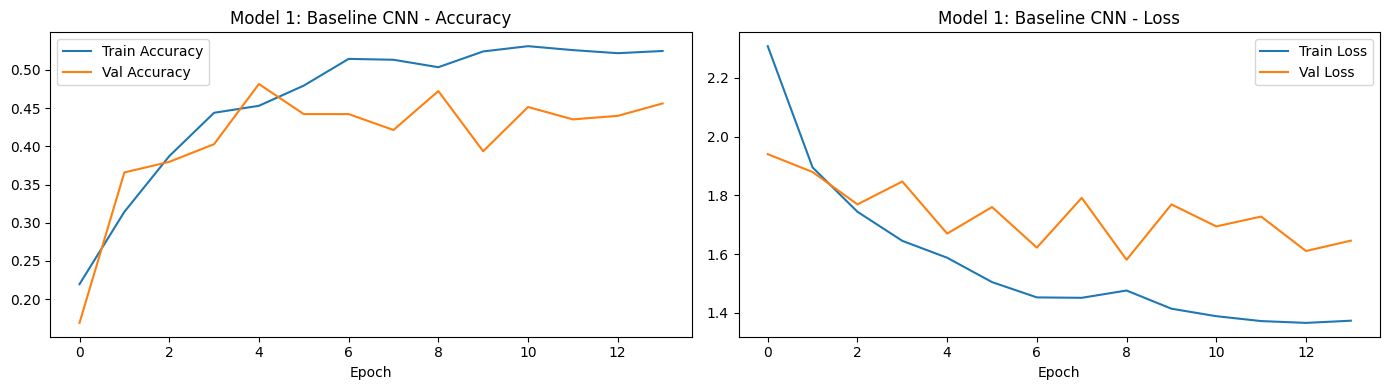

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, "Model 1: Baseline CNN")

#Model 2: Deeper CNN
An improved CNN with 3 convolutional blocks

In [ ]:
from tensorflow.keras.layers import BatchNormalization

model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="Deeper_CNN")

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,680,105 (33.11 MB)

 Trainable params: 8,679,145 (33.11 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.3486 - loss: 2.0576 - val_accuracy: 0.2106 - val_loss: 2.4700
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.4616 - loss: 1.6241 - val_accuracy: 0.1713 - val_loss: 2.4135
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.4564 - loss: 1.6194 - val_accuracy: 0.2106 - val_loss: 2.4747
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.4650 - loss: 1.5511 - val_accuracy: 0.2106 - val_loss: 2.3444
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 264s 5s/step - accuracy: 0.4725 - loss: 1.5294 - val_accuracy: 0.1620 - val_loss: 2.2922
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.5063 - loss: 1.4698 - val_accuracy: 0.2153 - val_loss: 2.3180
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 260s 5s/step - accuracy: 0.4943 - loss: 1.4751 - val_accuracy: 0.3241 - val_loss: 2.0657
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 257s 5s/step - accuracy: 0.5092 - loss: 1.4139 - val_accuracy: 0.3218 - v

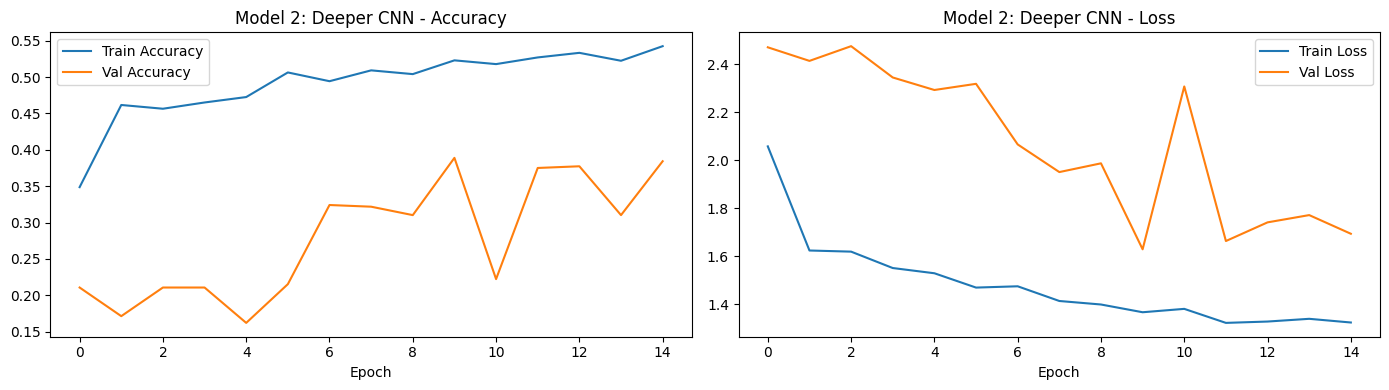

In [ ]:
history2 = model2.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

plot_history(history2, "Model 2: Deeper CNN")

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step

  Model 1: Baseline CNN — Test Evaluation
Test Accuracy : 29.66%
Test Loss     : 2.2540

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.12      0.22        16
      basal cell carcinoma       0.38      0.56      0.45        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.36      0.56      0.44        16
pigmented benign keratosis       0.22      0.81      0.35        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.50      0.67      0.57         3

                  accuracy                           0.30       118
                 macro avg       0.27      0.30      0.23       118
              weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


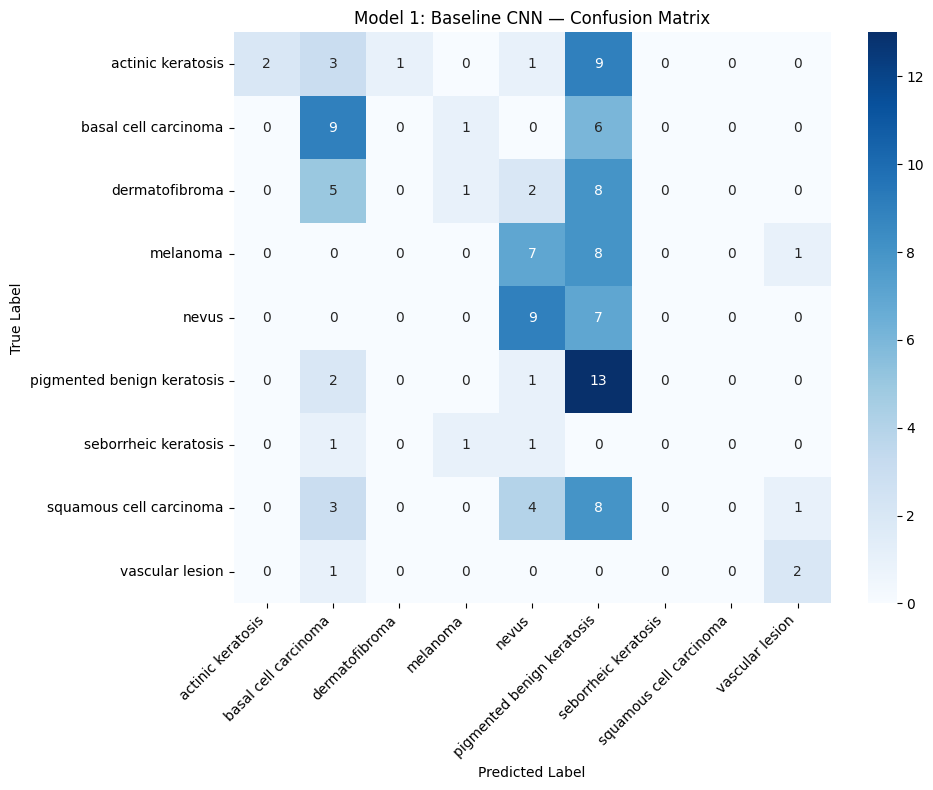

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step

  Model 2: Deeper CNN — Test Evaluation
Test Accuracy : 25.42%
Test Loss     : 2.1218

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.36      0.25      0.30        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.12      0.19      0.15        16
                     nevus       0.33      0.25      0.29        16
pigmented benign keratosis       0.25      0.88      0.39        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.27      0.25      0.26        16
           vascular lesion       1.00      0.33      0.50         3

                  accuracy                           0.25       118
                 macro avg       0.26      0.24      0.21       118
              weighted avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


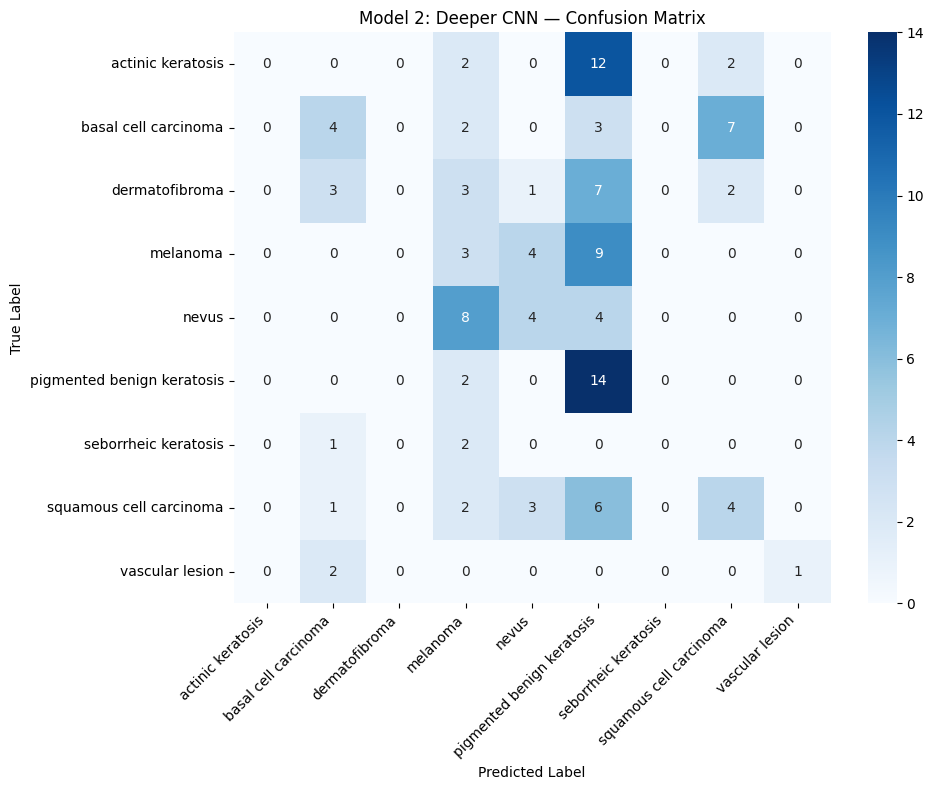

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_gen, model_name):
    test_gen.reset()
    preds = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes
    names  = list(test_gen.class_indices.keys())

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Evaluation")
    print(f"{'='*50}")
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"Test Accuracy : {acc*100:.2f}%")
    print(f"Test Loss     : {loss:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap='Blues')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

evaluate_model(model1, test_gen, "Model 1: Baseline CNN")
evaluate_model(model2, test_gen, "Model 2: Deeper CNN")

# 3 Part B Transfer Learning (MobileNetV2)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import Model, Input

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze pretrained layers

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model3 = Model(inputs, outputs, name="Transfer_Learning_MobileNetV2")
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Transfer_Learning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.2987 - loss: 2.0361 - val_accuracy: 0.4352 - val_loss: 1.6658
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 950ms/step - accuracy: 0.4019 - loss: 1.6618 - val_accuracy: 0.4352 - val_loss: 1.5817
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 939ms/step - accuracy: 0.4220 - loss: 1.5907 - val_accuracy: 0.4699 - val_loss: 1.6062
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 954ms/step - accuracy: 0.4369 - loss: 1.5582 - val_accuracy: 0.4560 - val_loss: 1.6038
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 918ms/step - accuracy: 0.4616 - loss: 1.4943 - val_accuracy: 0.4630 - val_loss: 1.5362
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 53s 956ms/step - accuracy: 0.4920 - loss: 1.4403 - val_accuracy: 0.4630 - val_loss: 1.5026
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 914ms/step - accuracy: 0.4748 - loss: 1.4285 - val_accuracy: 0.5069 - val_loss: 1.4868
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 933ms/step - accuracy: 0.5006 - loss: 1.4024 - val_accurac

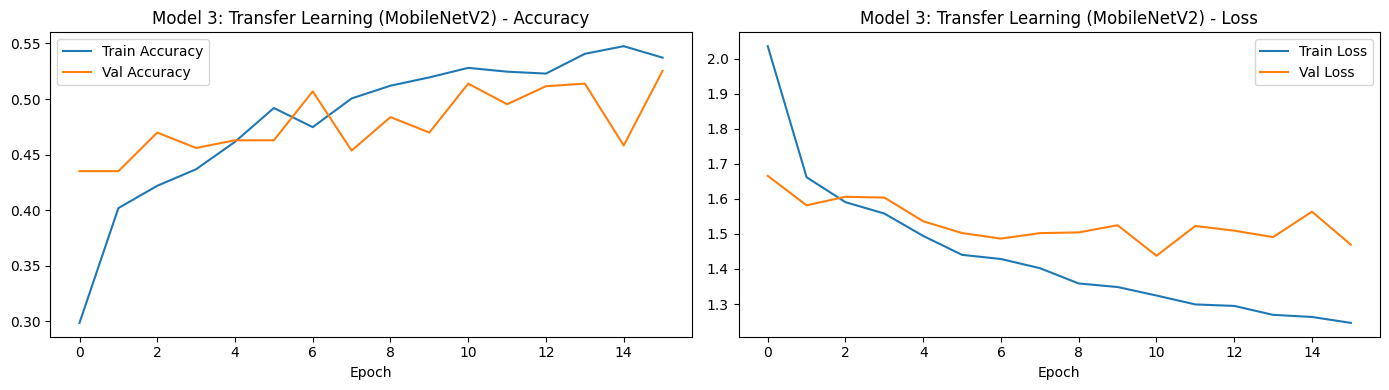

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step

  Model 3: Transfer Learning (MobileNetV2) — Test Evaluation
Test Accuracy : 33.90%
Test Loss     : 2.0188

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.06      0.12        16
      basal cell carcinoma       0.39      0.56      0.46        16
            dermatofibroma       0.44      0.25      0.32        16
                  melanoma       0.25      0.25      0.25        16
                     nevus       0.38      0.50      0.43        16
pigmented benign keratosis       0.28      0.69      0.39        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.60      1.00      0.75         3

                  accuracy                           0.34       118
                 macro avg       0.37      0.37      0.30       118
              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


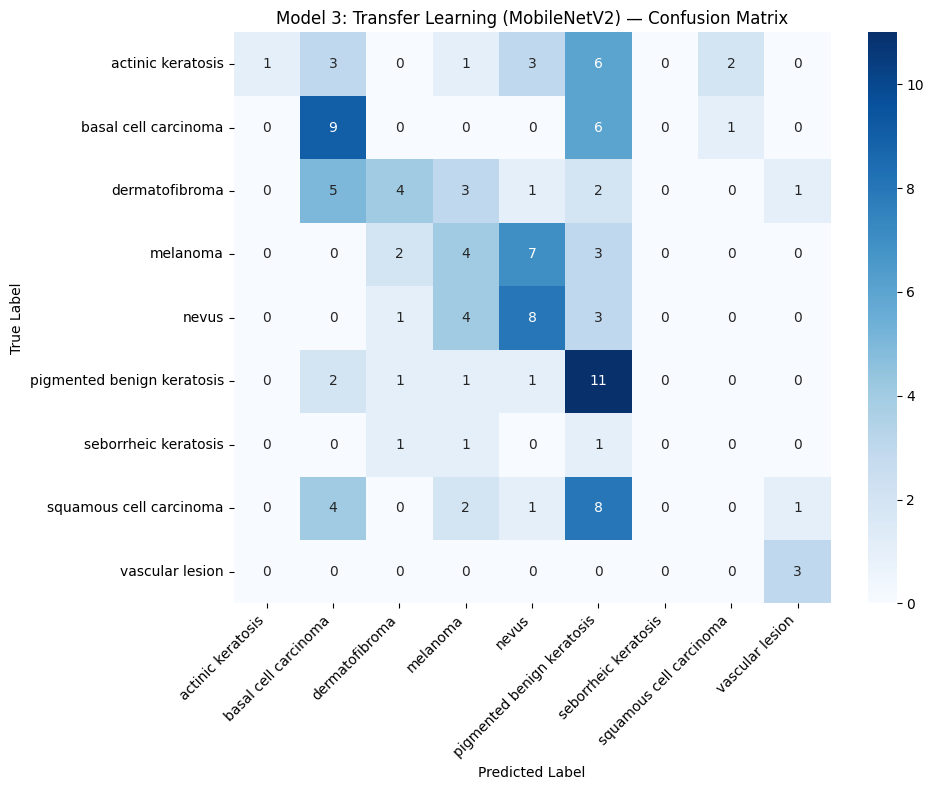

In [ ]:
history3 = model3.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

plot_history(history3, "Model 3: Transfer Learning (MobileNetV2)")
evaluate_model(model3, test_gen, "Model 3: Transfer Learning (MobileNetV2)")

# Results and Model Comparison

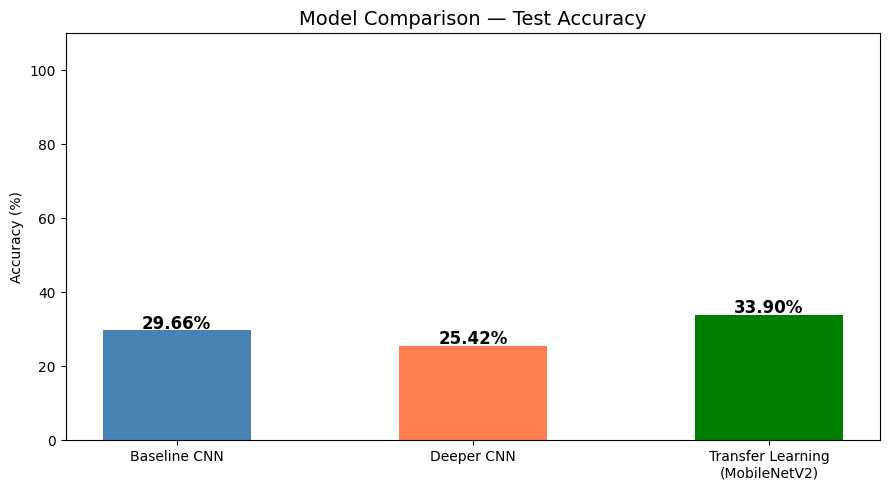


📊 FINAL COMPARISON
Model                            Test Accuracy
---------------------------------------------
Baseline CNN                            29.66%
Deeper CNN                              25.42%
Transfer Learning (MobileNetV2)          33.90%

✅ Best Model: Transfer Learning (MobileNetV2) (33.90%)


In [ ]:
# Get test accuracy for all 3 models
test_gen.reset(); _, acc1 = model1.evaluate(test_gen, verbose=0)
test_gen.reset(); _, acc2 = model2.evaluate(test_gen, verbose=0)
test_gen.reset(); _, acc3 = model3.evaluate(test_gen, verbose=0)

models     = ['Baseline CNN', 'Deeper CNN', 'Transfer Learning\n(MobileNetV2)']
accuracies = [acc1*100, acc2*100, acc3*100]
colors     = ['steelblue', 'coral', 'green']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.title('Model Comparison — Test Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

print("\n📊 FINAL COMPARISON")
print(f"{'Model':<30} {'Test Accuracy':>15}")
print("-" * 45)
for name, acc in zip(models, accuracies):
    print(f"{name.replace(chr(10),' '):<30} {acc:>14.2f}%")

best = models[accuracies.index(max(accuracies))].replace('\n',' ')
print(f"\n✅ Best Model: {best} ({max(accuracies):.2f}%)")